<a href="https://colab.research.google.com/github/DrAmitaB/AIML/blob/main/Dr_AmitaBeloskarPevekar_Foodhub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python Project : FoodHub Data Analysis

#1. Problem Statement

##1.1 Business Context

FoodHub is an online food delivery aggregator that connects customers with multiple restaurants through a single platform. Customers place orders via the app, restaurants prepare the food, and delivery partners deliver it to customers.

The company has collected data on customer orders, including details such as restaurant name, cuisine type, order cost, ratings, food preparation time and delivery time

FoodHub wants to analyze this data to understand customer behavior, restaurant performance, and delivery efficiency.

##1.2 Objectives
 To improve overall business operations and customer satisfaction, the objectives of this analysis are:

*   Identifying popular cuisines and restaurants
*   Analyzing customer satisfaction using ratings
*   Evaluating delivery and preparation times
*   Understanding order patterns (weekday vs weekend)










#2. Data Discription
Detailed data dictionary is given below:


| Column Name               | Description                                                                 |
| ------------------------- | --------------------------------------------------------------------------- |
| **order_id**              | Unique identifier for each order placed by a customer                       |
| **customer_id**           | Unique ID assigned to each customer                                         |
| **restaurant_name**       | Name of the restaurant from which the order was placed                      |
| **cuisine_type**          | Type of cuisine ordered (e.g., Italian, Chinese, Indian, etc.)              |
| **cost_of_the_order**     | Total cost of the order (in currency)                                       |
| **day_of_the_week**       | Indicates whether the order was placed on a **weekday** or **weekend**      |
| **rating**                | Rating given by the customer for the order (typically on a scale of 1 to 5) |
| **food_preparation_time** | Time (in minutes) taken by the restaurant to prepare the food               |
| **delivery_time**         | Time (in minutes) taken by the delivery person to deliver the order         |


#3. Import Important Libraries

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# to restrict the float value to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

#4. Load Dataset

##4.1 Importing Dataset

In [ ]:
data = pd.read_csv('/content/foodhub_order.csv')

##4.2 Copy of Dataset

In [ ]:
df = data.copy()

###4.3 View first and last 5 rows of dataset

In [ ]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24


In [ ]:
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.310,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.180,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.220,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.180,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.450,Weekend,Not given,28,24


#5. Understanding Data

###5.1 **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape

(1898, 9)

#### Observation: There are total 1898 rows and 9 columns

###5.2 **Question 2:** What are the datatypes of the different columns in the dataset?  [0.5 mark]

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
*   There are one float, four integer and four object columns in the dataset.
*   Rating column datatype is object instead of numeric, which may need datatype conversion.
*   Numerical columns include: cost_of_the_order, rating, food_preparation_time, delivery_time.
*   Categorical columns include: restaurant_name, cuisine_type, day_of_the_week.
*   Identifier columns include: order_id, customer_id.
*   All columns have equal non-null counts, indicating no missing values in the dataset.
*   The dataset uses 133.6+ KB memory, indicating it is manageable for analysis.



###5.3 Identifying Appropriateness of Datatype

In [ ]:
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

Observation:
*   Ratings are stored as strings (object)
*   There is a "Not given" value
*   This column should be numeric

###5.4 Coversion of Datatype

In [ ]:
# Convert "Not given" to NaN
df['rating'] = df['rating'].replace('Not given', np.nan)

# Convert to numeric
df['rating'] = pd.to_numeric(df['rating'])

# Verify
df['rating'].dtype

dtype('float64')

#### Observation:

*   The rating column is successfully converted to a numeric data type (float64).  
*   The presence of missing values (NaN) resulted in the column being stored as float instead of integer.
*   The column is now suitable for numerical analysis.

In [ ]:
# Re-checking datatype of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


#### Observation:


*   We can see that datatype of rating column is fixed
*   Now there are 6 Numerical columns and 3 object columns



#6. Missing Values
### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


#### Observation:


*   Yes, the dataset contains missing values in the rating column (736 entries). These missing values represent cases where customers did not provide ratings. Since this is a natural occurrence, the missing values were retained as NaN and handled appropriately during analysis by considering only available ratings where required.

In [ ]:
missing_pct = (736 / 1898) * 100
available_pct = (1162 / 1898) * 100
print(f"Missing Percentage: {missing_pct:.2f}%")
print(f"Available Percentage: {available_pct:.2f}%")

Missing Percentage: 38.78%
Available Percentage: 61.22%


#### Observation:
*   Out of 1898 total entries, 736 values in the rating column are missing.
*   This accounts for approximately 38.8% of the data, while 61.2% of the entries contain valid ratings.
*   The presence of missing values indicates that a significant number of customers did not provide feedback.
*   Although a considerable portion of ratings is missing, the majority of the data still contains valid ratings, allowing meaningful analysis of customer satisfaction. However, the missing values should be considered while interpreting the results.

### Treatment of Missing Rating

*   Kept it as NaN
*   As Missing = 'No feedback' is valid info (not an error)
*   It's real world behaviour, not random missing data.
*   Filling it with mean might distort data, giving bias unrealistic data.

#7. Statistical Summary


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.000,1477495.500,548.050,1476547.000,1477021.250,1477495.500,1477969.750,1478444.000
customer_id,1898.000,171168.478,113698.140,1311.000,77787.750,128600.000,270525.000,405334.000
cost_of_the_order,1898.000,16.499,7.484,4.470,12.080,14.140,22.297,35.410
rating,1162.000,4.344,0.741,3.000,4.000,5.000,5.000,5.000
food_preparation_time,1898.000,27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,1898.000,24.162,4.973,15.000,20.000,25.000,28.000,33.000


#### Observations:
1. Cost of the order:

- Mean ≈ ₹16.50, with a wide spread (std ≈ 7.48).

- Range: ₹4.47 – ₹35.41, showing both budget and premium orders.

- Median ≈ ₹14.14, slightly below the mean, suggesting a few high-cost outliers pulling the average upward.

2. Ratings:

- Mean ≈ 4.34/5, skewed toward high satisfaction.

- Coverage: 1162 ratings out of 1898 orders (~61%), meaning feedback is incomplete.

- Distribution: Most ratings are 4–5, with very few below 3.

3. Food preparation time:

- Mean ≈ 27.37 minutes, tightly clustered (std ≈ 4.63).

- Range: 20–35 minutes, showing consistent kitchen performance.

4. Delivery time:

- Mean ≈ 24.16 minutes, slightly more variable (std ≈ 4.97).

- Range: 15–33 minutes, indicating external factors (traffic, distance) cause variability.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:

min_time = df['food_preparation_time'].min()
mean_time = df['food_preparation_time'].mean()
max_time = df['food_preparation_time'].max()

min_time, mean_time, max_time

(20, np.float64(27.371970495258168), 35)

#### Observations:


*   The minimum food preparation time is 20 minutes

*   The average preparation time is 27.37 minutes

*   The maximum preparation time is 35 minutes.

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
df['rating'].isnull().sum()

np.int64(736)

#### Observation: 736 orders are not rated.

#8. Exploratory Data Analysis (EDA)

##8.1 Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

1. Cost of the Order

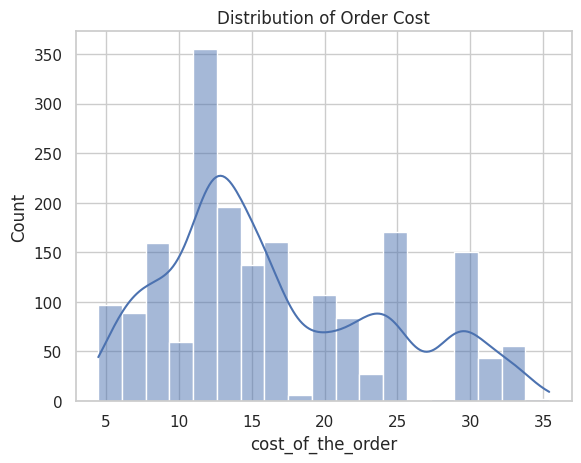

In [ ]:
sns.histplot(df['cost_of_the_order'], kde=True)
plt.title("Distribution of Order Cost")
plt.show()


#### Observations:
*   The distribution of order cost is slightly right-skewed, with most orders concentrated between 10 and 20 dollars. A few higher-value orders (above $25) are present, indicating occasional expensive purchases.


2. Rating

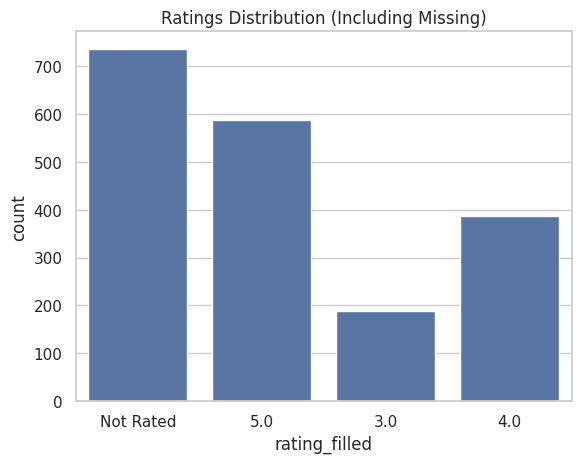

In [ ]:
df['rating_filled'] = df['rating'].fillna('Not Rated')
sns.countplot(x='rating_filled', data=df)
plt.title("Ratings Distribution (Including Missing)")
plt.show()


#### Observations:
*   A large number of orders are not rated, indicating that many customers do not provide feedback.
*   Among the rated orders, ratings of 4 and 5 dominate, showing high customer satisfaction, while very few low ratings are observed.



3. Food Preparation Time

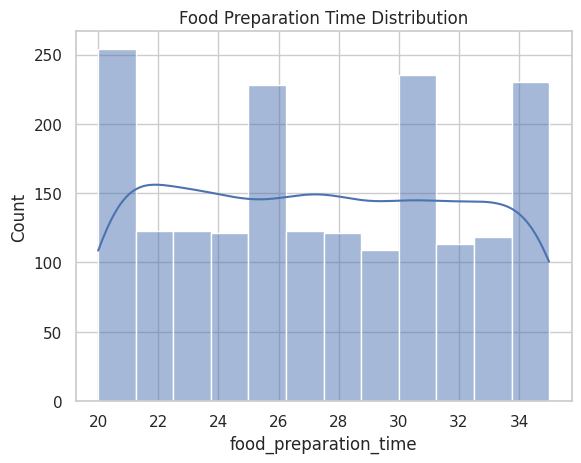

In [ ]:
sns.histplot(df['food_preparation_time'], kde=True)
plt.title("Food Preparation Time Distribution")
plt.show()

#### Observations:
*   Food preparation time is fairly evenly distributed between 20 and 35 minutes, with most values clustered around the mid-range (25–30 minutes). This suggests consistent preparation times across restaurants.


4. Delivery Time

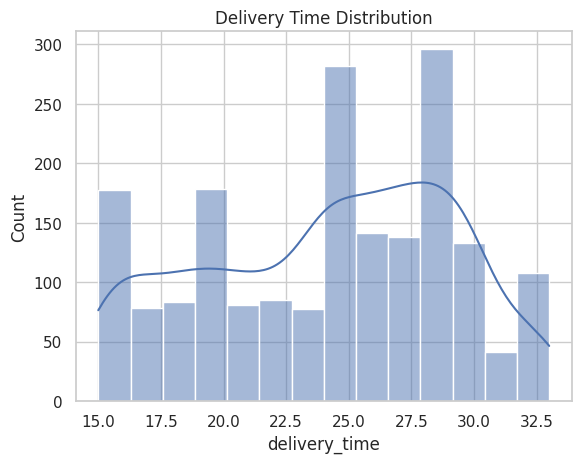

In [ ]:
sns.histplot(df['delivery_time'], kde=True)
plt.title("Delivery Time Distribution")
plt.show()

#### Observations:

*   Delivery time shows a moderate spread, with most deliveries occurring between 20 and 30 minutes.
*   There is a slight right skew, indicating that some orders take longer to deliver, possibly due to external factors like traffic or distance.



5. Cuisine Type

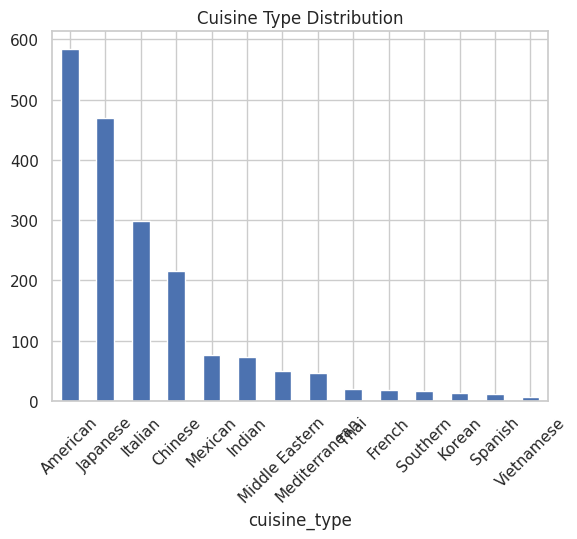

In [ ]:
df['cuisine_type'].value_counts().plot(kind='bar')
plt.title("Cuisine Type Distribution")
plt.xticks(rotation=45)
plt.show()

#### Observations:

*   American and Japanese cuisines are the most popular, followed by Italian and Chinese.
*   Other cuisines have significantly lower order counts, indicating that customer demand is concentrated among a few cuisine types.


6. Day of the Week

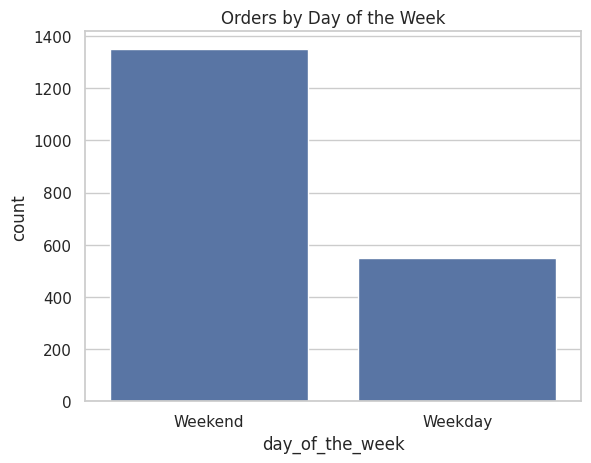

In [ ]:
sns.countplot(x='day_of_the_week', data=df)
plt.title("Orders by Day of the Week")
plt.show()

#### Observations:
*   Orders are significantly higher on weekends compared to weekdays, indicating increased customer activity during weekends.

7. Restaurant Name


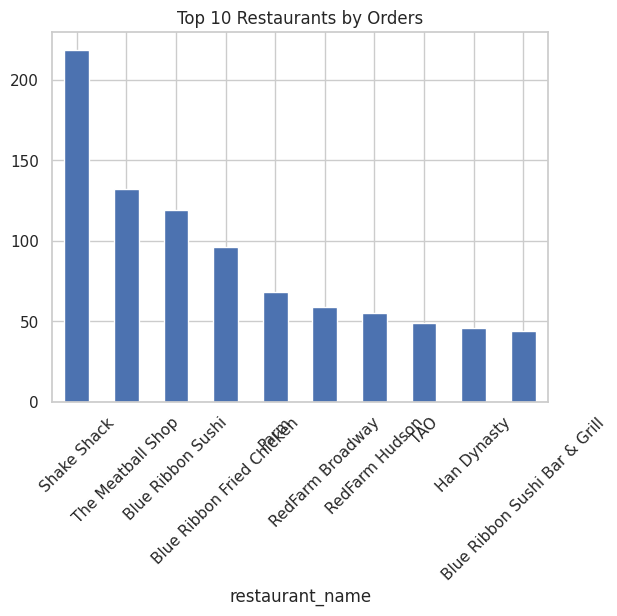

In [ ]:
df['restaurant_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Restaurants by Orders")
plt.xticks(rotation=45)
plt.show()

#### Observations:


*   The distribution of orders across restaurants shows that Shake Shack has the highest number of orders, followed by The Meatball Shop and Blue Ribbon Sushi.
*   There is a noticeable drop in order count after the top few restaurants, indicating that customer demand is concentrated among a small number of popular restaurants. The remaining restaurants have relatively similar but lower order volumes.

###8. Boxplot for Numerical Columns

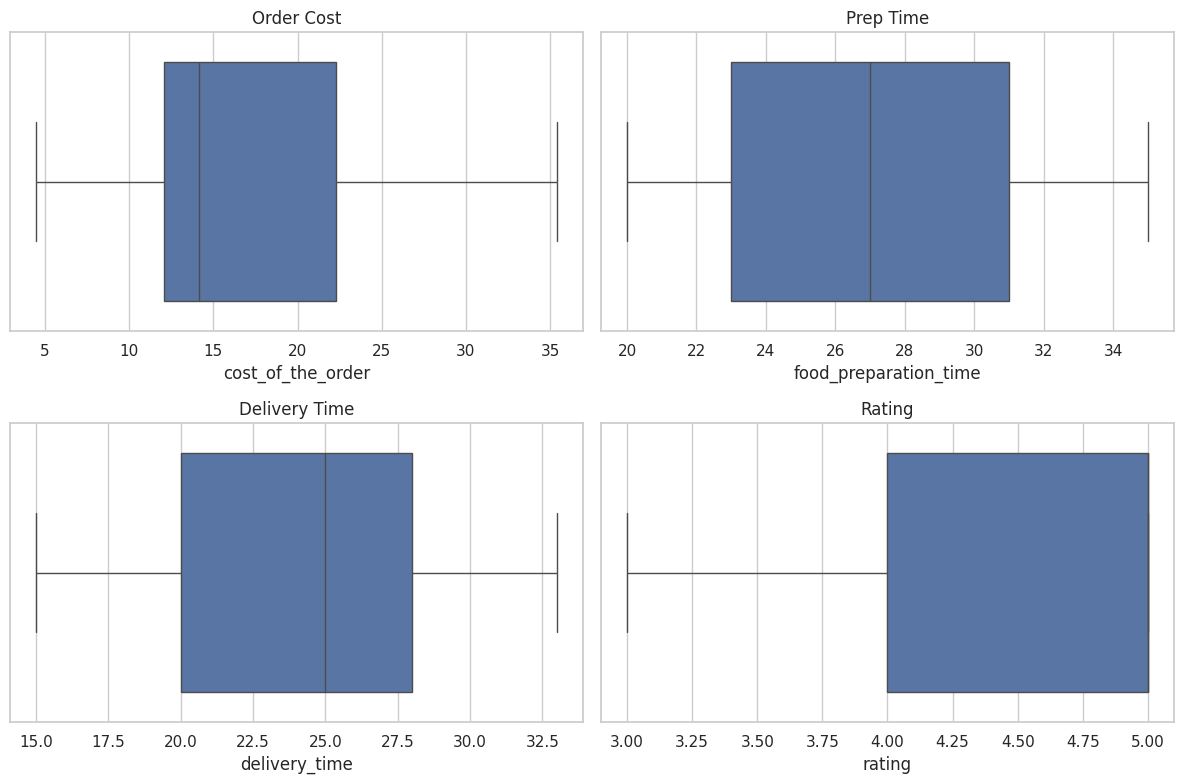

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.boxplot(x=df['cost_of_the_order'])
plt.title("Order Cost")

plt.subplot(2,2,2)
sns.boxplot(x=df['food_preparation_time'])
plt.title("Prep Time")

plt.subplot(2,2,3)
sns.boxplot(x=df['delivery_time'])
plt.title("Delivery Time")

plt.subplot(2,2,4)
sns.boxplot(x=df['rating'])
plt.title("Rating")

plt.tight_layout()
plt.show()

#### Observations:
1. The boxplot of cost_of_the_order shows a moderate spread with a median around the mid-range. There is a slight right skew, indicating the presence of some higher-value orders.

2. The food_preparation_time appears fairly symmetric with most values concentrated between approximately 23 to 31 minutes. There are no significant outliers, suggesting consistent preparation times across orders.

3. The delivery_time shows a moderate spread with a slight right skew, indicating that while most deliveries are completed within a typical time range, a few orders take longer than usual.

4. The rating variable is concentrated between 4 and 5, with a median close to 4. This indicates high customer satisfaction. The lower whisker extends to 3, showing that very few low ratings are present. No significant outliers are observed.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
*   Shake Shack has the highest number of orders, followed by The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm respectively.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observation:
*   American cuisine is most popular on weekends.




### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
total_orders = df.shape[0]

orders_above_20 = df[df['cost_of_the_order'] > 20].shape[0]

percentage = (orders_above_20 / total_orders) * 100

round(percentage, 2)

29.24

#### Observation:
*   29.24 % of the orders cost more than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
df['delivery_time'].mean()


np.float64(24.161749209694417)

#### Observation:
*   24 minutes is mean order delivary time.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
#df['customer_id'].value_counts().head(3)
df['customer_id'].value_counts().sort_values(ascending=False).iloc[:3]

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:

*   The top 3 most frequent customers are:

1. Customer ID 52832 with 13 orders  
2. Customer ID 47440 with 10 orders  
3. Customer ID 83287 with 9 orders  

These customers are eligible for the 20% discount voucher as they have placed the highest number of orders.




##8.2 Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]

1. Correlation Between Numerical Variables

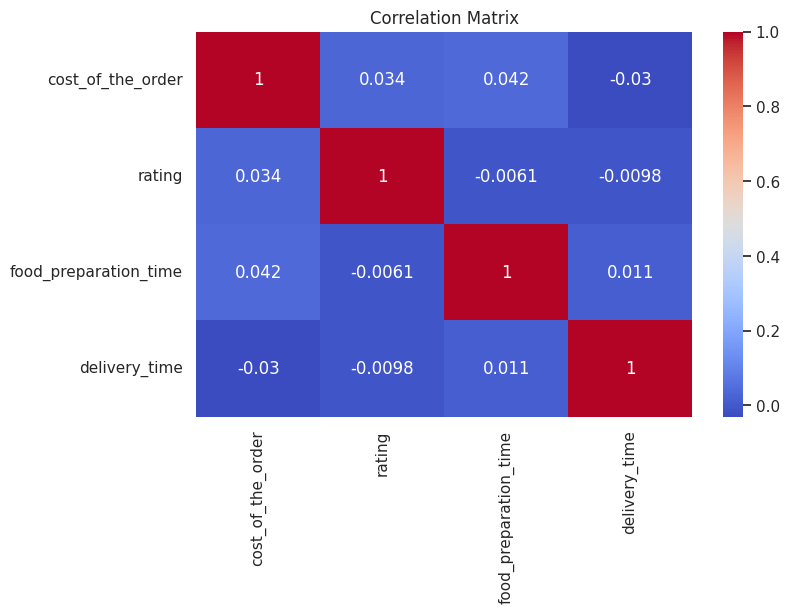

In [ ]:
plt.figure(figsize=(8,5))

corr = df[['cost_of_the_order','rating','food_preparation_time','delivery_time']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

#### Observations:

*   The correlation between cost_of_the_order and rating (0.034) is very weak, suggesting that higher-priced orders do not necessarily result in better customer satisfaction.
*   Similarly, food_preparation_time and delivery_time show a very weak positive correlation (0.011), indicating that longer preparation times tend to increase delivery time.
*   The relationship between cost_of_the_order and delivery_time (-0.03) is also negligible, suggesting that higher-cost orders do not necessarily take longer to deliver.
*   Overall, the correlation matrix indicates that there is no strong linear relationship between the numerical variables in the dataset. All correlation values are close to zero.

2. Cost vs Rating

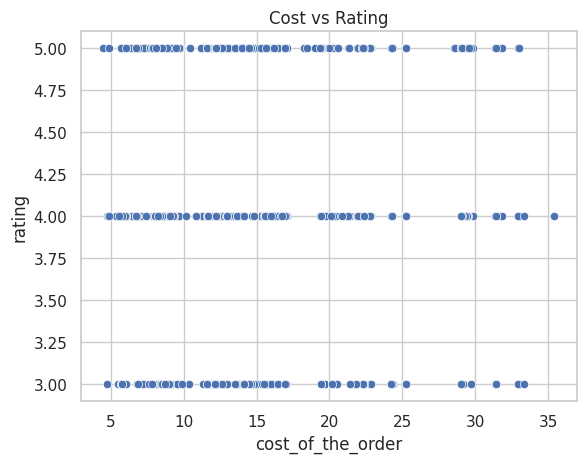

In [ ]:
sns.scatterplot(x='cost_of_the_order', y='rating', data=df)
plt.title("Cost vs Rating")
plt.show()

#### Observations:
*  The scatter plot shows that ratings are consistently high (mostly between 4 and 5) across all price ranges.
*   There is no visible trend or pattern, indicating that order cost does not significantly influence customer ratings.
*   Ratings remain consistently high across different price ranges, as both low-cost and high-cost orders receive similar ratings.
*   Hence, there is no strong relationship between order cost and customer rating.
  

3. Cuisine Type vs Rating

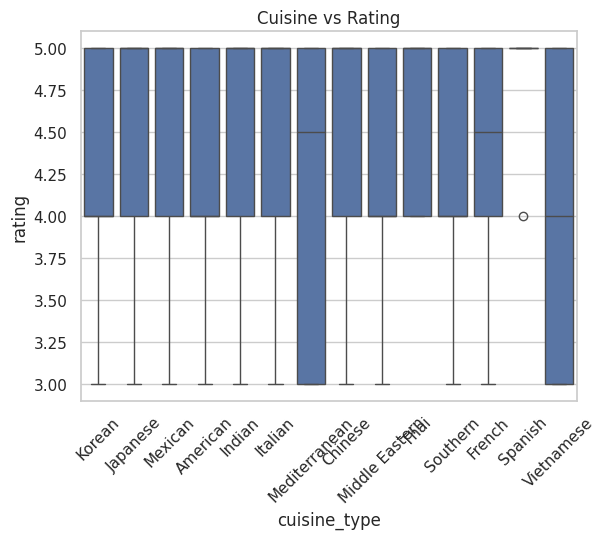

In [ ]:
sns.boxplot(x='cuisine_type', y='rating', data=df)
plt.xticks(rotation=45)
plt.title("Cuisine vs Rating")
plt.show()

#### Observations:
1.  Asian Cuisines (Korean, Japanese, Chinese, Thai, Vietnamese, Indian)
- Most Asian cuisines cluster near the top (median ~5), showing broad popularity and consistent satisfaction.

- Exception: Vietnamese aligns with Mediterranean in having slightly lower ratings, though still steady.

- Insight: Asian cuisines dominate the high-rating group, reflecting strong appeal across diverse flavor profiles.

2. European Cuisines (Italian, Mediterranean, French, Spanish)
- Italian & Mediterranean: Lower medians, suggesting weaker enthusiasm compared to peers.

- French: Strong ratings, consistent with the high cluster.

- Spanish: Exceptional — nearly all ratings at 5, with one outlier at 4.

- Insight: European cuisines show polarization — Spanish and French are adored, while Italian and Mediterranean lag behind.

3. Western Cuisines (American, Mexican, Southern)
- American & Mexican: High medians, consistent with the top cluster.

- Southern: Also strong, though slightly less concentrated than Spanish.

- Insight: Western cuisines are generally well-liked, but they don’t reach the near-perfect consensus of Spanish cuisine.

#### Insight:
- most cuisines are loved, Spanish is adored almost universally, and Mediterranean/Vietnamese are consistently “good but not great.”




4. Day of the Week vs Delivery Time

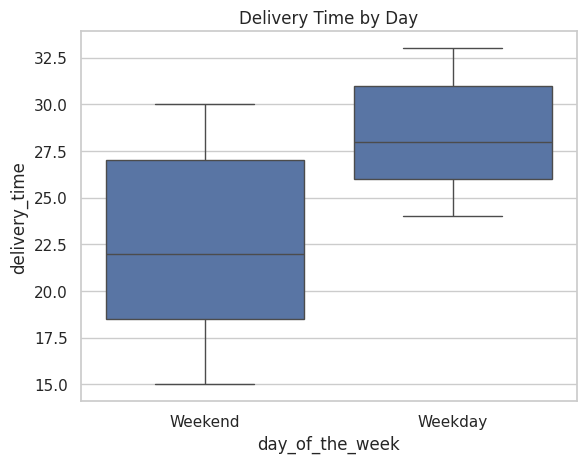

In [ ]:
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title("Delivery Time by Day")
plt.show()

#### Observations:
- Weekdays: Median delivery time is higher (~28 minutes) with a narrower IQR, meaning slower but more predictable deliveries.

- Weekends: Median delivery time is lower (~22 minutes) but the IQR is broader, showing faster average performance but greater variability.
#### Insight
- Weekdays offer consistency but at the cost of speed, while weekends deliver speed but with less reliability.



5. Cuisine Type vs Cost

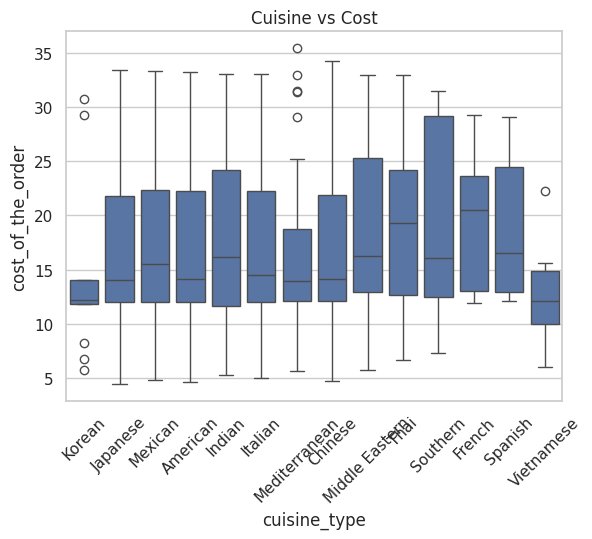

In [ ]:
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.xticks(rotation=45)
plt.title("Cuisine vs Cost")
plt.show()

#### Observations:
Different cuisines have varying price distributions, indicating that some cuisines are generally more expensive than others.

1. Asian Cuisines (Korean, Japanese, Chinese, Thai, Indian, Vietnamese)

- Japanese: High median, wide IQR, premium positioning. Outliers on the upper end show very expensive orders.

- Korean: Mid-range median, moderate IQR. Outliers on the higher side indicate occasional premium-priced meals.

- Chinese & Thai: Moderate medians, wider spreads, showing accessible but variable pricing.

- Indian: Low median, narrow IQR, no notable outliers — very affordable and consistent.

- Vietnamese: Low median, narrow IQR, but with high-cost outliers — rare premium offerings.

2. European Cuisines (Italian, Mediterranean, French, Spanish, Middle Eastern)

- French & Spanish: High medians, wide IQRs, premium positioning. Outliers extend costs even higher, reinforcing luxury perception.

- Italian: Mid-range median, moderate spread, relatively stable pricing.

- Mediterranean: Moderate median, wider IQR, with high-cost outliers — inconsistent pricing across restaurants.

- Middle Eastern: Mid-to-high median, moderate spread, no extreme outliers.

3. Western Cuisines (American, Mexican, Southern)

- American: Moderate median, balanced spread, no extreme outliers.

- Mexican & Southern: Low medians, narrow IQRs, affordable and consistent, no notable outliers.

### Insights
- Asian: Offers the widest spectrum — from budget (Indian, Vietnamese) to premium (Japanese). Outliers in Korean and Vietnamese show potential for niche upscale positioning.

- European: Strong premium positioning (French, Spanish), but Italian/Mediterranean show inconsistency. Mediterranean’s outliers highlight uneven market perception.

- Western: Affordable and reliable, appealing to mass-market diners. Lack of outliers suggests stable, predictable pricing but less opportunity for premium differentiation.

6. Preparation Time vs Delivery Time

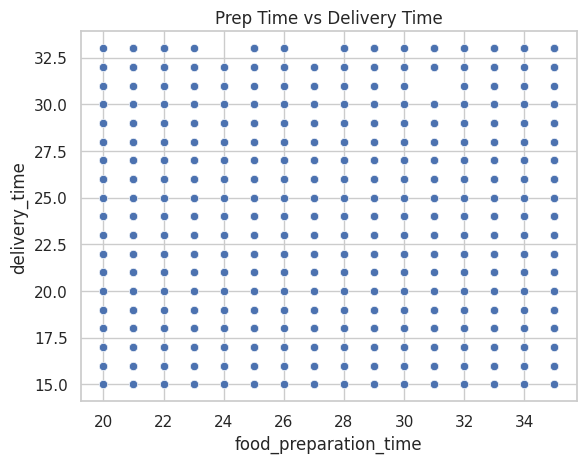

In [ ]:
sns.scatterplot(x='food_preparation_time', y='delivery_time', data=df)
plt.title("Prep Time vs Delivery Time")
plt.show()

#### Observations:

- Prep times range from ~20–35 minutes, delivery times from ~15–33 minutes.

- The scatter shows a uniform distribution — no clear correlation between prep time and delivery time.

- This suggests that longer prep does not necessarily mean longer delivery, and vice versa.
####Insight
- Operational independence: Kitchen efficiency (prep time) and logistics (delivery time) appear to function separately.

- Variability in delivery times is not explained by prep duration, meaning delays are likely due to external factors (traffic, routing, staffing).

- Improving delivery logistics could yield faster service without requiring changes in kitchen prep processes.
- Overall, prep and delivery times are independent — kitchens are consistent, but logistics need optimization.

7. Rated vs Not Rated

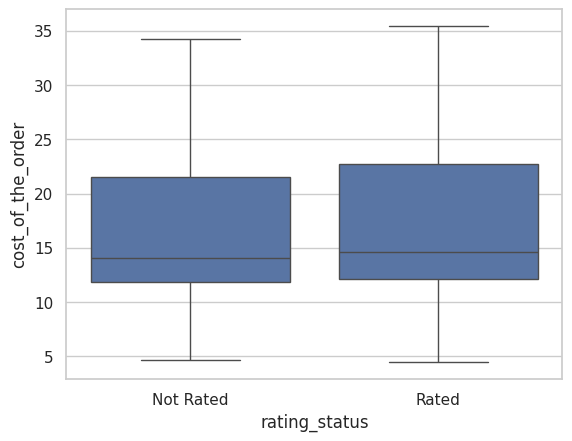

In [ ]:
df['rating_status'] = df['rating'].apply(lambda x: 'Rated' if pd.notnull(x) else 'Not Rated')

sns.boxplot(x='rating_status', y='cost_of_the_order', data=df)
plt.show()

#### Observations:
- Rated orders: Higher median cost, wider IQR, and more variability. Customers tend to rate when they spend more, but costs vary significantly.

- Not Rated orders: Lower median cost, narrower IQR, and more consistent pricing. Smaller, predictable orders are less likely to be rated.

- Outliers appear in the Rated group, showing some very high-cost orders that stand out.

#### Insight
- Customer behavior: People are more inclined to leave ratings when they place higher-value or premium orders.

- Lower-cost, consistent orders (Not Rated) may deliver satisfaction but don’t motivate feedback.

- Ratings are skewed toward premium experiences, which could bias perception of overall service quality.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Step 1: Remove missing ratings
rating_df = df[df['rating'].notnull()]

# Step 2: Group by restaurant
restaurant_stats = rating_df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Step 3: Apply conditions
qualified_restaurants = restaurant_stats[
    (restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)
]

qualified_restaurants

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328
Blue Ribbon Sushi,73,4.219
Shake Shack,133,4.278
The Meatball Shop,84,4.512


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
def commission(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

df['revenue'] = df['cost_of_the_order'].apply(commission)

total_revenue = df['revenue'].sum()

round(total_revenue, 2)

np.float64(6166.3)

#### Observation:
- The total revenue generated by the company across all orders is approximately 6166.30 dollars.
- This revenue is earned through commission on each order, with higher commissions (25%) applied to orders above 20 dollars and lower commissions (15%) applied to orders between 5 dollars and 20 dollars.
#### Insights:
- This indicates that higher value orders contribute significantly more to the company's revenue. Therefore, encouraging customers to place higher-cost orders can help increase overall profitability.

### Profitability per Cuisine

In [ ]:
profitability = df.groupby('cuisine_type').agg(
    total_revenue=('revenue', 'sum'),          # actual profit
    avg_revenue=('revenue', 'mean'),           # per order profit
    avg_cost=('cost_of_the_order', 'mean'),    # pricing level
    order_count=('order_id', 'count')          # demand
).sort_values(by='total_revenue', ascending=False)

profitability

,total_revenue,avg_revenue,avg_cost,order_count
cuisine_type,,,,
American,1878.274,3.216,16.320,584
Japanese,1478.245,3.145,16.305,470
Italian,966.885,3.245,16.419,298
Chinese,690.040,3.209,16.305,215
Mexican,256.693,3.334,16.933,77
Indian,246.994,3.383,16.920,73
Middle Eastern,193.553,3.950,18.821,49
Mediterranean,136.328,2.964,15.475,46
Thai,78.052,4.108,19.208,19


### Average Revenue Per Cuisine

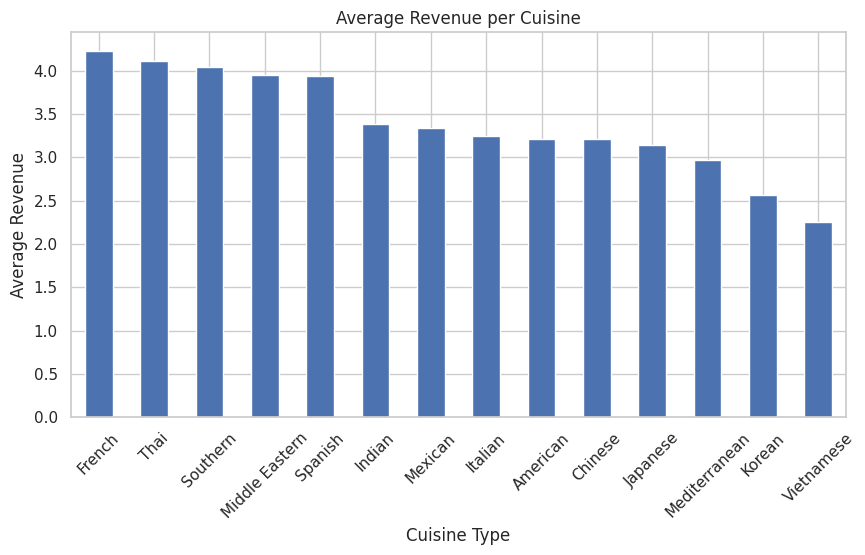

In [ ]:
plt.figure(figsize=(10,5))

profitability.sort_values(by='avg_revenue', ascending=False)['avg_revenue']\
    .plot(kind='bar')

plt.title("Average Revenue per Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)

plt.show()

#### Observations:
- Cuisines such as French, Thai, Southern, Middle Eastern and Spanish have the highest average revenue per order, indicating that these cuisines generate higher commission per transaction.
-  On the other hand, cuisines like Korean and Vietnamese have the lowest average revenue, indicating lower-priced orders or fewer high-value transactions.

#### Insights:
- This suggests that premium cuisines (e.g., French, Thai) can be positioned as high-value offerings. Increasing their visibility or promoting premium dishes could help boost overall revenue per order.

### Total Revenue Per Cuisine

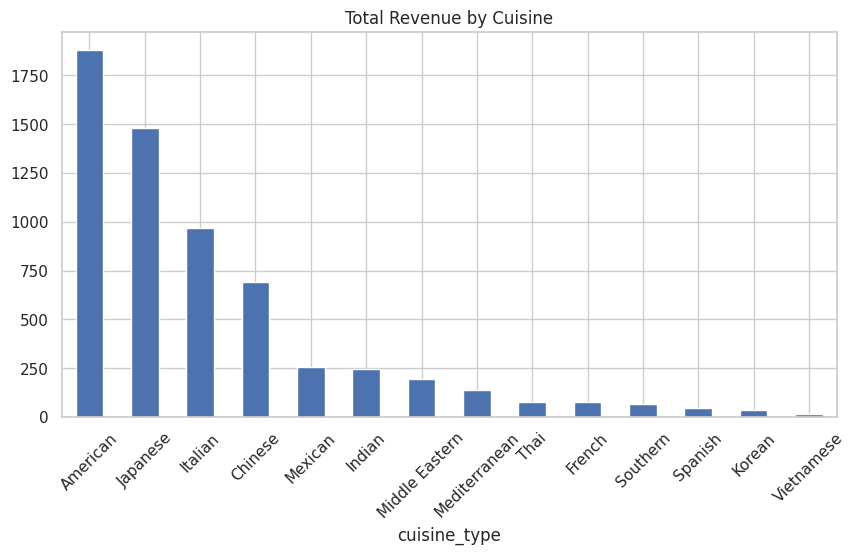

In [ ]:
profitability['total_revenue'].plot(kind='bar', figsize=(10,5))
plt.title("Total Revenue by Cuisine")
plt.xticks(rotation=45)
plt.show()

#### Observations:
- American cuisine generates the highest total revenue, followed by Japanese, Italian and chinese cuisines. This is primarily due to their high order volumes.
- Chinese cuisine also contributes significantly, while cuisines like Korean and Vietnamese generate very low total revenue due to low demand.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Step 1: Total time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Step 2: Count orders > 60 mins
orders_above_60 = df[df['total_time'] > 60].shape[0]

# Step 3: Total orders
total_orders = df.shape[0]

# Step 4: Percentage
percentage = (orders_above_60 / total_orders) * 100

round(percentage, 2)

10.54

#### Observations:
- About 10.54% of orders take more than 60 minutes from placement to delivery (including preparation and delivery time).
#### Insight:
- This indicates that while the majority of orders are fulfilled within an hour, a small but notable fraction exceed this threshold.
- Operationally, this could highlight potential bottlenecks in either food preparation or delivery logistics that affect customer satisfaction.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
df.groupby('day_of_the_week')['delivery_time'].mean().round(2)

,delivery_time
day_of_the_week,
Weekday,28.340
Weekend,22.470


#### Observations:
- The mean delivery time is longer on weekdays (28.34 minutes) compared to weekends (22.47 minutes). This shows that deliveries are generally faster during weekends, with about a 6-minute improvement in average delivery time.
#### Insight:
- This suggests that either demand is lower, traffic conditions are better, or operational efficiency improves during weekends.

##9. Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

###9.1 Conclusions:

- The analysis shows that customer satisfaction is generally high, with most ratings between 4 and 5 across all cuisines. There is no strong relationship between cost, delivery time, and ratings, indicating that customers are consistently satisfied regardless of price or time.

- From a profitability perspective, cuisines such as American, Japanese, and Italian generate the highest total revenue due to high order volumes. In contrast, cuisines like French and Thai generate higher revenue per order but contribute less overall due to lower demand.

- Delivery times are slightly higher on weekdays compared to weekends, suggesting possible operational inefficiencies during weekdays. Additionally, a significant portion of customers do not provide ratings, which limits the depth of feedback analysis.

- Overall, business performance is primarily driven by demand (order volume) rather than per-order profitability.

###9.2 Recommendations:

1. Promote High-Demand Cuisines:
   Focus marketing efforts on cuisines such as American, Japanese, Italian and Chinese, as they contribute the most to total revenue.

2. Increase Visibility of Premium Cuisines:
   Cuisines like French, Thai, Southern and Spanish have high average revenue per order. Promoting these can help increase overall profitability.

3. Improve Underperforming Cuisines:
   Cuisines such as Korean and Vietnamese show low demand and revenue. The company should investigate and improve quality, pricing, or visibility.

4. Encourage Customer Feedback:
   Since many customers do not provide ratings, incentives such as discounts or reward points should be introduced to increase feedback participation.

5. Optimize Weekday Delivery Operations:
   As delivery times are higher on weekdays, improving logistics, delivery staffing, and route optimization can enhance efficiency.

6. Balance Volume and Value Strategy:
   The company should maintain a balance between high-volume cuisines and high-value cuisines to maximize overall revenue and profitability.